In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from src import config

RAW = Path("..") / "data" / "raw"
PROC = Path("..") / "data" / "processed"
REP = Path("..") / "reports"

In [2]:
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
df["вердикт"] = df["добавка"].map(config.VERDICT)

wb = pd.read_excel(RAW / "prices_wb.xlsx")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.merge(med, on="добавка", how="left")
df.shape

(25, 7)

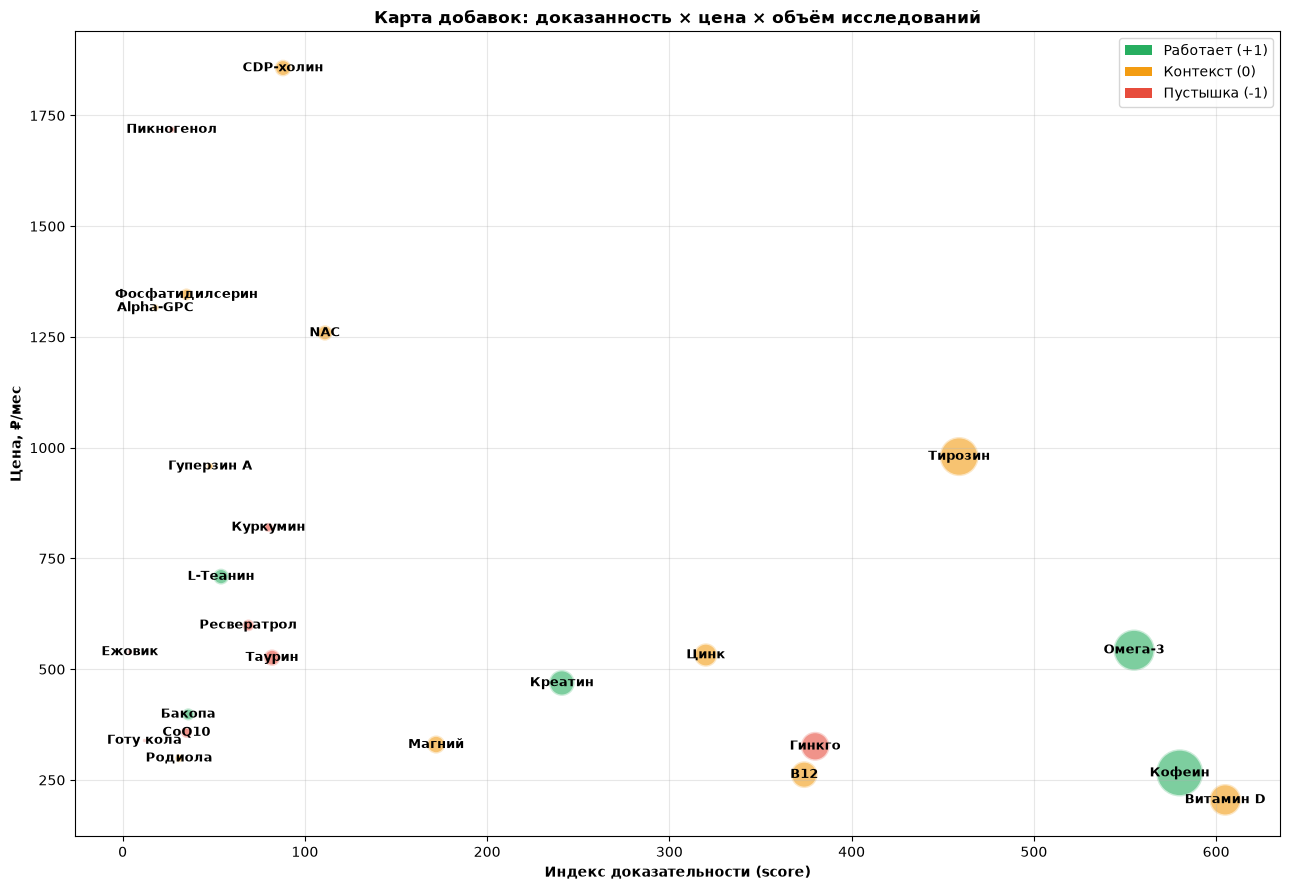

In [3]:
fig, ax = plt.subplots(figsize=(13, 9))
colors = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
ax.scatter(df["score"], df["цена_мес"], s=df["rct"]*3,
           c=df["вердикт"].map(colors), alpha=0.6, edgecolors="white", linewidth=2)
for _, r in df.iterrows():
    ax.annotate(r["добавка"], (r["score"], r["цена_мес"]),
                fontsize=9, ha="center", va="center", fontweight="bold")
ax.set_xlabel("Индекс доказательности (score)", fontweight="bold")
ax.set_ylabel("Цена, ₽/мес", fontweight="bold")
ax.set_title("Карта добавок: доказанность × цена × объём исследований", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#27ae60", label="Работает (+1)"),
                   Patch(facecolor="#f39c12", label="Контекст (0)"),
                   Patch(facecolor="#e74c3c", label="Пустышка (-1)")], loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REP / "bubble_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
df.to_csv(PROC / "evidence_scored.csv", index=False, encoding="utf-8-sig")
print("processed обновлён:", df.shape)

processed обновлён: (25, 7)
